In [ ]:
!nvidia-smi

Sun Oct  4 05:04:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!git clone https://github.com/karpathy/nanoGPT.git
%cd /content/nanoGPT
!git rev-parse HEAD

Cloning into 'nanoGPT'...
remote: Enumerating objects: 689, done.
remote: Total 689 (delta 0), reused 0 (delta 0), pack-reused 689 (from 1)
Receiving objects: 100% (689/689), 981.25 KiB | 27.26 MiB/s, done.
Resolving deltas: 100% (380/380), done.
/content/nanoGPT
3adf61e154c3fe3fca428ad6bc3818b27a3b8291


In [ ]:
!python data/shakespeare_char/prepare.py

length of dataset in characters: 1,115,394
all the unique characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocab size: 65
train has 1,003,854 tokens
val has 111,540 tokens


In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

print("\nDefault training settings:")
print(open("config/train_shakespeare_char.py").read())

PyTorch version: 2.11.0+cu130
GPU available: True
GPU name: Tesla T4

Default training settings:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3 # with baby networks can afford to go a bit higher
max_iters = 5000
lr_decay_iters = 5000 # make equal to max_iters usually
min_lr = 1e-4 # learning_rate / 10 usually
beta2 = 0.9

In [ ]:
!python -u train.py config/train_shakespeare_char.py --dtype=float16 --compile=False --out_dir=out-baseline 2>&1 | tee baseline_training.log

python3: can't open file '/content/train.py': [Errno 2] No such file or directory


In [ ]:
from pathlib import Path

print("nanoGPT folder exists:", Path("/content/nanoGPT").exists())
print("Training file exists:", Path("/content/nanoGPT/train.py").exists())

nanoGPT folder exists: False
Training file exists: False


In [ ]:
!git clone https://github.com/karpathy/nanoGPT.git /content/nanoGPT
%cd /content/nanoGPT
!git checkout 3adf61e154c3fe3fca428ad6bc3818b27a3b8291
!python data/shakespeare_char/prepare.py


Cloning into '/content/nanoGPT'...
remote: Enumerating objects: 689, done.
remote: Total 689 (delta 0), reused 0 (delta 0), pack-reused 689 (from 1)
Receiving objects: 100% (689/689), 981.25 KiB | 2.93 MiB/s, done.
Resolving deltas: 100% (380/380), done.
/content/nanoGPT
Note: switching to '3adf61e154c3fe3fca428ad6bc3818b27a3b8291'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at 3adf61e Update README to mention nanochat and deprecation
length of dataset in characters: 1,115,394
all the unique characters: 
 !$&

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

MessageError: Error: credential propagation was unsuccessful

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path
import torch

save_folder = Path("/content/drive/MyDrive/Homework1_nanoGPT")
save_folder.mkdir(parents=True, exist_ok=True)

print("Results folder:", save_folder)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Results folder: /content/drive/MyDrive/Homework1_nanoGPT
GPU available: True
GPU: Tesla T4


In [ ]:
%cd /content/nanoGPT

!python -u train.py config/train_shakespeare_char.py --dtype=float16 --compile=False --out_dir="/content/drive/MyDrive/Homework1_nanoGPT/out-baseline" 2>&1 | tee "/content/drive/MyDrive/Homework1_nanoGPT/baseline_training.log"

/content/nanoGPT
Overriding config with config/train_shakespeare_char.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3 # with baby networks can afford to go a bit higher
max_iters = 5000
lr_decay_iters = 5000 # make equal to max_iters usually
min_lr = 1e-4 # learning_rate / 10 usually
beta2 = 0.99 # make a bit bigger b

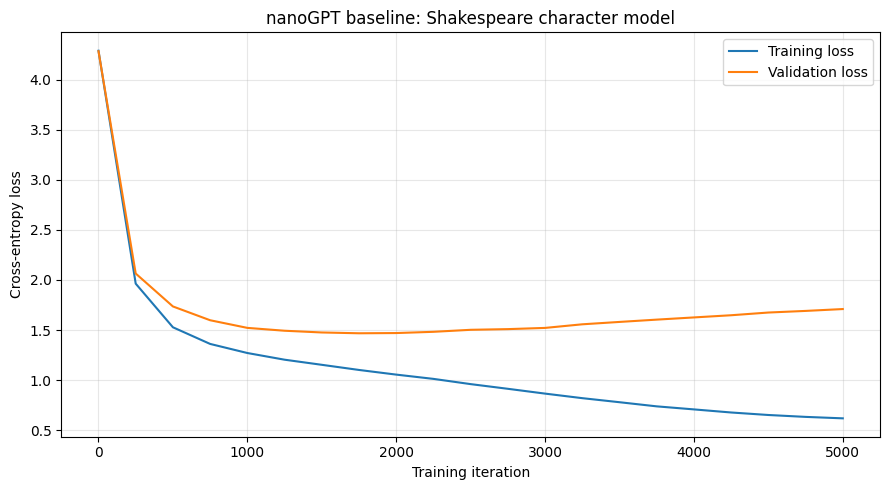

Best validation loss: 1.4677 at step 1750
Plot and CSV saved to Google Drive.


In [ ]:
from pathlib import Path
import re
import csv
import matplotlib.pyplot as plt

folder = Path("/content/drive/MyDrive/Homework1_nanoGPT")
log = (folder / "baseline_training.log").read_text()

# Extract training and validation losses measured during evaluation.
matches = re.findall(
    r"step (\d+): train loss ([\d.]+), val loss ([\d.]+)",
    log
)
rows = [(int(s), float(t), float(v)) for s, t, v in matches]

if not rows:
    raise ValueError("No evaluation losses found in the log.")

steps, train_losses, val_losses = zip(*rows)

# Save the values for later comparisons.
with (folder / "baseline_losses.csv").open("w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["step", "train_loss", "val_loss"])
    writer.writerows(rows)

plt.figure(figsize=(9, 5))
plt.plot(steps, train_losses, label="Training loss")
plt.plot(steps, val_losses, label="Validation loss")
plt.xlabel("Training iteration")
plt.ylabel("Cross-entropy loss")
plt.title("nanoGPT baseline: Shakespeare character model")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(folder / "baseline_loss_plot.png", dpi=300)
plt.show()

best = min(rows, key=lambda row: row[2])
print(f"Best validation loss: {best[2]:.4f} at step {best[0]}")
print("Plot and CSV saved to Google Drive.")

In [ ]:
from pathlib import Path

model_path = Path("/content/nanoGPT/model.py")
code = model_path.read_text()

# Show the normalization implementation.
start = code.index("class LayerNorm")
end = code.index("class CausalSelfAttention")
print(code[start:end])

# Show a Transformer block.
start = code.index("class Block")
end = code.index("@dataclass", start)
print(code[start:end])


class LayerNorm(nn.Module):
    """ LayerNorm but with an optional bias. PyTorch doesn't support simply bias=False """

    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None

    def forward(self, input):
        return F.layer_norm(input, self.weight.shape, self.weight, self.bias, 1e-5)


class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = LayerNorm(config.n_embd, bias=config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = LayerNorm(config.n_embd, bias=config.bias)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x




In [ ]:
from pathlib import Path
import subprocess

repo = Path("/content/nanoGPT")
folder = Path("/content/drive/MyDrive/Homework1_nanoGPT")
assert folder.is_dir(), "Connect Google Drive before continuing."

# Read the unchanged baseline directly from the recorded Git version.
baseline = subprocess.check_output(
    ["git", "show", "3adf61e154c3fe3fca428ad6bc3818b27a3b8291:model.py"],
    cwd=repo,
    text=True,
)
(folder / "model_baseline.py").write_text(baseline)

rmsnorm = '''class RMSNorm(nn.Module):
    """Root mean square normalization with a learned scale."""

    def __init__(self, ndim, bias=False):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.eps = 1e-5

    def forward(self, x):
        # Compute the squared mean in float32 for numerical stability.
        x_float = x.float()
        normalized = x_float * torch.rsqrt(
            x_float.pow(2).mean(dim=-1, keepdim=True) + self.eps
        )
        return normalized.to(x.dtype) * self.weight


'''

start = baseline.index("class LayerNorm")
end = baseline.index("class CausalSelfAttention")

modified = baseline[:start] + rmsnorm + baseline[end:]
modified = modified.replace("LayerNorm(", "RMSNorm(")

(repo / "model.py").write_text(modified)
(folder / "model_rmsnorm.py").write_text(modified)

print("Baseline code saved to Drive.")
print("RMSNorm code saved to Drive and installed as model.py.")
print("Number of RMSNorm call sites:", modified.count("= RMSNorm("))

Baseline code saved to Drive.
RMSNorm code saved to Drive and installed as model.py.
Number of RMSNorm call sites: 3


In [ ]:
%cd /content/nanoGPT

import importlib
import torch
import model

importlib.reload(model)

# A small model makes this check quick.
test_model = model.GPT(model.GPTConfig(
    block_size=16,
    vocab_size=65,
    n_layer=1,
    n_head=2,
    n_embd=32,
    dropout=0.0,
))

inputs = torch.randint(0, 65, (2, 16))
targets = torch.randint(0, 65, (2, 16))

logits, loss = test_model(inputs, targets)
assert torch.isfinite(loss), "Loss is not finite."

loss.backward()
assert all(
    torch.isfinite(p.grad).all()
    for p in test_model.parameters()
    if p.grad is not None
), "A gradient is not finite."

print("Output shape:", tuple(logits.shape))
print("RMSNorm forward and backward check passed.")

/content/nanoGPT
number of parameters: 0.01M
Output shape: (2, 16, 65)
RMSNorm forward and backward check passed.


In [ ]:
%cd /content/nanoGPT

!python -u train.py config/train_shakespeare_char.py --dtype=float16 --compile=False --out_dir="/content/drive/MyDrive/Homework1_nanoGPT/out-rmsnorm" 2>&1 | tee "/content/drive/MyDrive/Homework1_nanoGPT/rmsnorm_training.log"

/content/nanoGPT
Overriding config with config/train_shakespeare_char.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3 # with baby networks can afford to go a bit higher
max_iters = 5000
lr_decay_iters = 5000 # make equal to max_iters usually
min_lr = 1e-4 # learning_rate / 10 usually
beta2 = 0.99 # make a bit bigger b

baseline: best validation loss = 1.4677 at step 1750
rmsnorm: best validation loss = 1.4665 at step 1750


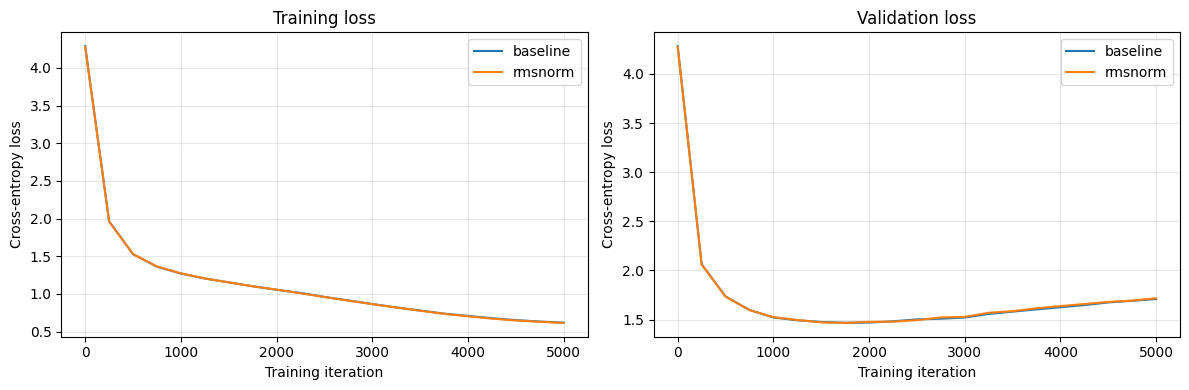

In [ ]:
from pathlib import Path
import re
import csv
import matplotlib.pyplot as plt

folder = Path("/content/drive/MyDrive/Homework1_nanoGPT")
results = {}

for name in ["baseline", "rmsnorm"]:
    log = (folder / f"{name}_training.log").read_text()
    matches = re.findall(
        r"step (\d+): train loss ([\d.]+), val loss ([\d.]+)",
        log
    )
    rows = [(int(s), float(t), float(v)) for s, t, v in matches]
    if not rows:
        raise ValueError(f"No evaluation losses found for {name}.")
    results[name] = rows

    with (folder / f"{name}_losses.csv").open("w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["step", "train_loss", "val_loss"])
        writer.writerows(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, rows in results.items():
    steps, train_losses, val_losses = zip(*rows)
    axes[0].plot(steps, train_losses, label=name)
    axes[1].plot(steps, val_losses, label=name)

    best = min(rows, key=lambda row: row[2])
    print(
        f"{name}: best validation loss = {best[2]:.4f} "
        f"at step {best[0]}"
    )

for ax, title in zip(axes, ["Training loss", "Validation loss"]):
    ax.set_title(title)
    ax.set_xlabel("Training iteration")
    ax.set_ylabel("Cross-entropy loss")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(folder / "baseline_vs_rmsnorm.png", dpi=300)
plt.show()

In [ ]:
from pathlib import Path

folder = Path("/content/drive/MyDrive/Homework1_nanoGPT")
baseline = (folder / "model_baseline.py").read_text()

start = baseline.index("class MLP")
end = baseline.index("class Block", start)
print(baseline[start:end])

class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu    = nn.GELU()
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x




In [ ]:
from pathlib import Path

repo = Path("/content/nanoGPT")
folder = Path("/content/drive/MyDrive/Homework1_nanoGPT")
baseline = (folder / "model_baseline.py").read_text()

swiglu = '''class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        hidden_dim = (8 * config.n_embd) // 3
        self.c_gate = nn.Linear(
            config.n_embd, hidden_dim, bias=config.bias
        )
        self.c_fc = nn.Linear(
            config.n_embd, hidden_dim, bias=config.bias
        )
        self.c_proj = nn.Linear(
            hidden_dim, config.n_embd, bias=config.bias
        )
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = F.silu(self.c_gate(x)) * self.c_fc(x)
        x = self.c_proj(x)
        return self.dropout(x)


'''

start = baseline.index("class MLP")
end = baseline.index("class Block", start)
modified = baseline[:start] + swiglu + baseline[end:]

(repo / "model.py").write_text(modified)
(folder / "model_swiglu.py").write_text(modified)

print("SwiGLU model installed and saved to Drive.")
print("Baseline LayerNorm and positional embeddings retained.")
print("SwiGLU hidden size for embedding dimension 384:", (8 * 384) // 3)

SwiGLU model installed and saved to Drive.
Baseline LayerNorm and positional embeddings retained.
SwiGLU hidden size for embedding dimension 384: 1024


In [ ]:
%cd /content/nanoGPT

import importlib.util
from pathlib import Path
import torch

folder = Path("/content/drive/MyDrive/Homework1_nanoGPT")

def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

baseline = load_module("baseline_check", folder / "model_baseline.py")
swiglu = load_module("swiglu_check", folder / "model_swiglu.py")

# Compare MLP sizes at the actual training dimensions.
config = baseline.GPTConfig(n_embd=384, bias=False, dropout=0.2)
baseline_mlp = baseline.MLP(config)
swiglu_mlp = swiglu.MLP(config)

for name, mlp in [("Baseline", baseline_mlp), ("SwiGLU", swiglu_mlp)]:
    count = sum(p.numel() for p in mlp.parameters())
    print(f"{name} MLP parameters: {count:,}")

print("SwiGLU hidden size:", swiglu_mlp.c_fc.out_features)

# Check forward and backward passes with a small model.
test_model = swiglu.GPT(swiglu.GPTConfig(
    block_size=16,
    vocab_size=65,
    n_layer=1,
    n_head=2,
    n_embd=32,
    dropout=0.0,
    bias=False,
))

inputs = torch.randint(0, 65, (2, 16))
targets = torch.randint(0, 65, (2, 16))

logits, loss = test_model(inputs, targets)
assert torch.isfinite(loss), "Loss is not finite."
loss.backward()

assert all(
    torch.isfinite(p.grad).all()
    for p in test_model.parameters()
    if p.grad is not None
), "A gradient is not finite."

print("Output shape:", tuple(logits.shape))
print("SwiGLU forward and backward check passed.")

/content/nanoGPT
Baseline MLP parameters: 1,179,648
SwiGLU MLP parameters: 1,179,648
SwiGLU hidden size: 1024
number of parameters: 0.01M
Output shape: (2, 16, 65)
SwiGLU forward and backward check passed.


In [ ]:
%cd /content/nanoGPT

!python -u train.py config/train_shakespeare_char.py --dtype=float16 --compile=False --out_dir="/content/drive/MyDrive/Homework1_nanoGPT/out-swiglu" 2>&1 | tee "/content/drive/MyDrive/Homework1_nanoGPT/swiglu_training.log"

/content/nanoGPT
Overriding config with config/train_shakespeare_char.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3 # with baby networks can afford to go a bit higher
max_iters = 5000
lr_decay_iters = 5000 # make equal to max_iters usually
min_lr = 1e-4 # learning_rate / 10 usually
beta2 = 0.99 # make a bit bigger b

baseline: best validation loss = 1.4677 at step 1750
swiglu: best validation loss = 1.4953 at step 1250


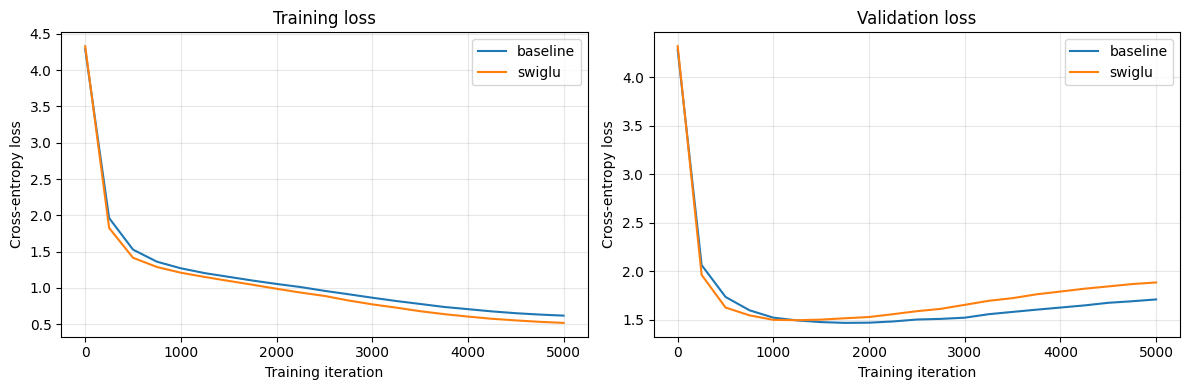

In [ ]:
from pathlib import Path
import re
import csv
import matplotlib.pyplot as plt

folder = Path("/content/drive/MyDrive/Homework1_nanoGPT")
results = {}

for name in ["baseline", "swiglu"]:
    log = (folder / f"{name}_training.log").read_text()
    matches = re.findall(
        r"step (\d+): train loss ([\d.]+), val loss ([\d.]+)",
        log
    )
    rows = [(int(s), float(t), float(v)) for s, t, v in matches]
    if not rows:
        raise ValueError(f"No evaluation losses found for {name}.")
    results[name] = rows

    with (folder / f"{name}_losses.csv").open("w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["step", "train_loss", "val_loss"])
        writer.writerows(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, rows in results.items():
    steps, train_losses, val_losses = zip(*rows)
    axes[0].plot(steps, train_losses, label=name)
    axes[1].plot(steps, val_losses, label=name)

    best = min(rows, key=lambda row: row[2])
    print(
        f"{name}: best validation loss = {best[2]:.4f} "
        f"at step {best[0]}"
    )

for ax, title in zip(axes, ["Training loss", "Validation loss"]):
    ax.set_title(title)
    ax.set_xlabel("Training iteration")
    ax.set_ylabel("Cross-entropy loss")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(folder / "baseline_vs_swiglu.png", dpi=300)
plt.show()

In [ ]:
from pathlib import Path

folder = Path("/content/drive/MyDrive/Homework1_nanoGPT")
baseline = (folder / "model_baseline.py").read_text()

lines = baseline.splitlines()

for index, line in enumerate(lines):
    if "wpe" in line or "pos_emb" in line:
        print(f"\n--- Around line {index + 1} ---")
        for nearby in lines[max(0, index - 2):index + 3]:
            print(nearby)


--- Around line 128 ---
        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            wpe = nn.Embedding(config.block_size, config.n_embd),
            drop = nn.Dropout(config.dropout),
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),

--- Around line 159 ---
        n_params = sum(p.numel() for p in self.parameters())
        if non_embedding:
            n_params -= self.transformer.wpe.weight.numel()
        return n_params


--- Around line 178 ---
        # forward the GPT model itself
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (t, n_embd)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:

--- Around line 179 ---
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)
        pos_emb = self.transf

In [ ]:
from pathlib import Path

repo = Path("/content/nanoGPT")
folder = Path("/content/drive/MyDrive/Homework1_nanoGPT")
baseline = (folder / "model_baseline.py").read_text()

# Remove the positional embedding module and its forward-pass lookup.
lines = [
    line for line in baseline.splitlines(keepends=True)
    if "wpe = nn.Embedding(" not in line
    and "pos_emb = self.transformer.wpe(pos)" not in line
    and "self.transformer.wpe.weight = nn.Parameter(" not in line
]
modified = "".join(lines)

# Feed only token embeddings into the Transformer.
old = "self.transformer.drop(tok_emb + pos_emb)"
assert old in modified
modified = modified.replace(old, "self.transformer.drop(tok_emb)")

# Update parameter counting now that positional embeddings are absent.
old = (
    "        if non_embedding:\n"
    "            n_params -= self.transformer.wpe.weight.numel()\n"
)
assert old in modified
modified = modified.replace(old, "")

# Verify the active positional-embedding references are gone.
assert "self.transformer.wpe" not in modified
assert "tok_emb + pos_emb" not in modified
compile(modified, "model_nope.py", "exec")

(repo / "model.py").write_text(modified)
(folder / "model_nope.py").write_text(modified)

print("NoPE model installed and saved to Drive.")
print("Learned positional embedding module removed.")
print("Baseline LayerNorm, GELU, and causal attention retained.")

NoPE model installed and saved to Drive.
Learned positional embedding module removed.
Baseline LayerNorm, GELU, and causal attention retained.


In [ ]:
%cd /content/nanoGPT

import importlib
import torch
import model

importlib.reload(model)

test_model = model.GPT(model.GPTConfig(
    block_size=16,
    vocab_size=65,
    n_layer=1,
    n_head=2,
    n_embd=32,
    dropout=0.0,
))

assert "wpe" not in test_model.transformer, \
    "Positional embeddings are still present."

inputs = torch.randint(0, 65, (2, 16))
targets = torch.randint(0, 65, (2, 16))

logits, loss = test_model(inputs, targets)
assert torch.isfinite(loss), "Loss is not finite."

loss.backward()
assert all(
    torch.isfinite(p.grad).all()
    for p in test_model.parameters()
    if p.grad is not None
), "A gradient is not finite."

print("Positional embeddings: removed")
print("Output shape:", tuple(logits.shape))
print("NoPE forward and backward check passed.")

/content/nanoGPT
number of parameters: 0.01M
Positional embeddings: removed
Output shape: (2, 16, 65)
NoPE forward and backward check passed.


In [ ]:
%cd /content/nanoGPT

!python -u train.py config/train_shakespeare_char.py --dtype=float16 --compile=False --out_dir="/content/drive/MyDrive/Homework1_nanoGPT/out-nope" 2>&1 | tee "/content/drive/MyDrive/Homework1_nanoGPT/nope_training.log"

/content/nanoGPT
Overriding config with config/train_shakespeare_char.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3 # with baby networks can afford to go a bit higher
max_iters = 5000
lr_decay_iters = 5000 # make equal to max_iters usually
min_lr = 1e-4 # learning_rate / 10 usually
beta2 = 0.99 # make a bit bigger b

In [ ]:
from pathlib import Path

folder = Path("/content/drive/MyDrive/Homework1_nanoGPT")
baseline = (folder / "model_baseline.py").read_text()

start = baseline.index("class CausalSelfAttention")
end = baseline.index("class MLP", start)
print(baseline[start:end])

class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        # regularization
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.dropout = config.dropout
        # flash attention make GPU go brrrrr but support is only in PyTorch >= 2.0
        self.flash = hasattr(torch.nn.functional, 'scaled_dot_product_attention')
        if not self.flash:
            print("WARNING: using slow attention. Flash Attention requires PyTorch >= 2.0")
            # causal mask to ensure that attention is only a

In [ ]:
from pathlib import Path

repo = Path("/content/nanoGPT")
folder = Path("/content/drive/MyDrive/Homework1_nanoGPT")

# NoPE already contains the baseline architecture with absolute
# positional embeddings removed.
code = (folder / "model_nope.py").read_text()

rope_function = '''def apply_rope(x):
    # x shape: (batch, heads, sequence_length, head_dimension)
    head_dim = x.size(-1)
    assert head_dim % 2 == 0

    # Calculate angles in float32.
    frequencies = 10000.0 ** (
        -torch.arange(
            0, head_dim, 2, device=x.device, dtype=torch.float32
        ) / head_dim
    )
    positions = torch.arange(
        x.size(-2), device=x.device, dtype=torch.float32
    )
    angles = positions[:, None] * frequencies[None, :]

    cos = angles.cos()[None, None, :, :]
    sin = angles.sin()[None, None, :, :]

    # Rotate adjacent pairs of coordinates.
    x_float = x.float()
    even = x_float[..., 0::2]
    odd = x_float[..., 1::2]

    rotated = torch.stack(
        (even * cos - odd * sin,
         even * sin + odd * cos),
        dim=-1,
    )
    return rotated.flatten(-2).to(x.dtype)


'''

# Insert the helper before the attention class.
marker = "class CausalSelfAttention"
assert code.count(marker) == 1
code = code.replace(marker, rope_function + marker, 1)

# Rotate queries and keys immediately before attention.
marker = "        # causal self-attention;"
assert code.count(marker) == 1
code = code.replace(
    marker,
    "        q = apply_rope(q)\n"
    "        k = apply_rope(k)\n\n" + marker,
    1,
)

compile(code, "model_rope.py", "exec")

(repo / "model.py").write_text(code)
(folder / "model_rope.py").write_text(code)

print("RoPE model installed and saved to Drive.")
print("RoPE applied to queries and keys; values unchanged.")
print("Absolute positional embeddings removed.")
print("Baseline LayerNorm and GELU retained.")

RoPE model installed and saved to Drive.
RoPE applied to queries and keys; values unchanged.
Absolute positional embeddings removed.
Baseline LayerNorm and GELU retained.


In [ ]:
%cd /content/nanoGPT

import importlib
import torch
import model

importlib.reload(model)
torch.manual_seed(42)

# 1. Rotating a vector should preserve its length.
x = torch.randn(2, 6, 16, 64)
rotated = model.apply_rope(x)

torch.testing.assert_close(
    x.norm(dim=-1),
    rotated.norm(dim=-1),
    rtol=1e-5,
    atol=1e-5,
)

# 2. Position zero has angle zero, so it should be unchanged.
torch.testing.assert_close(rotated[:, :, 0], x[:, :, 0])

print("RoPE rotation checks passed.")

# 3. Check the full model's forward and backward passes.
test_model = model.GPT(model.GPTConfig(
    block_size=16,
    vocab_size=65,
    n_layer=1,
    n_head=2,
    n_embd=32,
    dropout=0.0,
))

assert "wpe" not in test_model.transformer

inputs = torch.randint(0, 65, (2, 16))
targets = torch.randint(0, 65, (2, 16))

logits, loss = test_model(inputs, targets)
assert torch.isfinite(loss), "Loss is not finite."

loss.backward()
assert all(
    torch.isfinite(p.grad).all()
    for p in test_model.parameters()
    if p.grad is not None
), "A gradient is not finite."

print("Output shape:", tuple(logits.shape))
print("RoPE forward and backward check passed.")

/content/nanoGPT
RoPE rotation checks passed.
number of parameters: 0.01M
Output shape: (2, 16, 65)
RoPE forward and backward check passed.


In [ ]:
%cd /content/nanoGPT

!python -u train.py config/train_shakespeare_char.py --dtype=float16 --compile=False --out_dir="/content/drive/MyDrive/Homework1_nanoGPT/out-rope" 2>&1 | tee "/content/drive/MyDrive/Homework1_nanoGPT/rope_training.log"

/content/nanoGPT
Overriding config with config/train_shakespeare_char.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3 # with baby networks can afford to go a bit higher
max_iters = 5000
lr_decay_iters = 5000 # make equal to max_iters usually
min_lr = 1e-4 # learning_rate / 10 usually
beta2 = 0.99 # make a bit bigger b

baseline: best validation loss = 1.4677 at step 1750
nope: best validation loss = 1.5264 at step 2750
rope: best validation loss = 1.4741 at step 1500


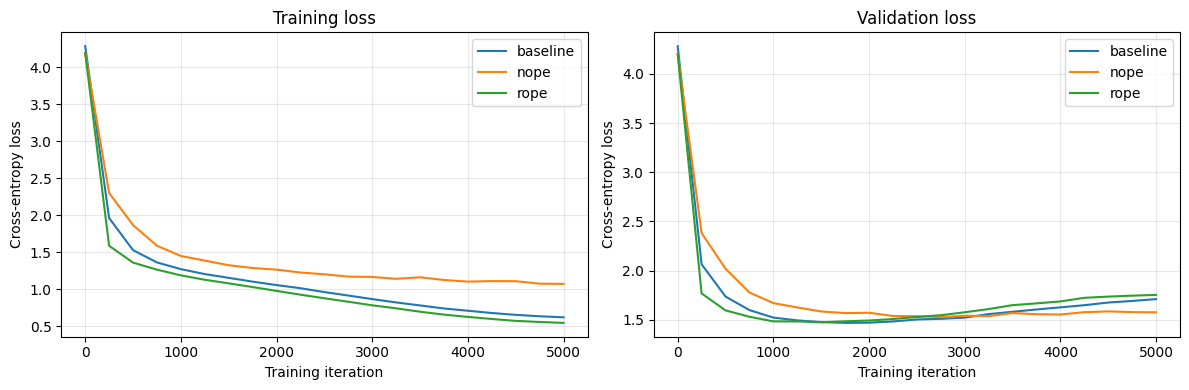

Comparison plot and CSV files saved to Drive.


In [ ]:
from pathlib import Path
import re
import csv
import matplotlib.pyplot as plt

folder = Path("/content/drive/MyDrive/Homework1_nanoGPT")
results = {}
summary = []

for name in ["baseline", "nope", "rope"]:
    log = (folder / f"{name}_training.log").read_text()
    matches = re.findall(
        r"step (\d+): train loss ([\d.]+), val loss ([\d.]+)",
        log
    )
    rows = [(int(s), float(t), float(v)) for s, t, v in matches]
    if not rows:
        raise ValueError(f"No evaluation losses found for {name}.")
    assert rows[-1][0] == 5000, f"{name} log is incomplete."
    results[name] = rows

    with (folder / f"{name}_losses.csv").open("w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["step", "train_loss", "val_loss"])
        writer.writerows(rows)

    best = min(rows, key=lambda row: row[2])
    summary.append([
        name, best[2], best[0], rows[-1][1], rows[-1][2]
    ])
    print(
        f"{name}: best validation loss = {best[2]:.4f} "
        f"at step {best[0]}"
    )

with (folder / "positional_comparison.csv").open("w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "model", "best_val_loss", "best_step",
        "final_train_loss", "final_val_loss"
    ])
    writer.writerows(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, rows in results.items():
    steps, train_losses, val_losses = zip(*rows)
    axes[0].plot(steps, train_losses, label=name)
    axes[1].plot(steps, val_losses, label=name)

for ax, title in zip(axes, ["Training loss", "Validation loss"]):
    ax.set_title(title)
    ax.set_xlabel("Training iteration")
    ax.set_ylabel("Cross-entropy loss")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(folder / "positional_encoding_comparison.png", dpi=300)
plt.show()

print("Comparison plot and CSV files saved to Drive.")

In [ ]:
from pathlib import Path

repo = Path("/content/nanoGPT")
folder = Path("/content/drive/MyDrive/Homework1_nanoGPT")
code = (folder / "model_baseline.py").read_text()

# Change the projection to produce fewer key and value heads.
old = (
    "        self.c_attn = nn.Linear(config.n_embd, "
    "3 * config.n_embd, bias=config.bias)"
)
new = """        assert config.n_head % 2 == 0
        self.n_kv_head = config.n_head // 2
        self.head_dim = config.n_embd // config.n_head
        self.kv_dim = self.n_kv_head * self.head_dim
        self.c_attn = nn.Linear(
            config.n_embd,
            config.n_embd + 2 * self.kv_dim,
            bias=config.bias,
        )"""

assert code.count(old) == 1
code = code.replace(old, new, 1)

# Replace the query/key/value splitting and reshaping.
start = code.index("        q, k, v  = self.c_attn(x)")
end = code.index("        # causal self-attention;", start)

new_forward = """        q, k, v = self.c_attn(x).split(
            [self.n_embd, self.kv_dim, self.kv_dim], dim=2
        )

        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_kv_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_kv_head, self.head_dim).transpose(1, 2)

        # Each adjacent pair of query heads shares one key/value head.
        k = k.repeat_interleave(2, dim=1)
        v = v.repeat_interleave(2, dim=1)

"""

code = code[:start] + new_forward + code[end:]
compile(code, "model_gqa.py", "exec")

(repo / "model.py").write_text(code)
(folder / "model_gqa.py").write_text(code)

print("GQA model installed and saved to Drive.")
print("Training model: 6 query heads, 3 key heads, 3 value heads.")
print("Baseline LayerNorm, GELU, and positional embeddings retained.")

# Check the training script's seed without changing it.
print("\nSeed-related lines in train.py:")
for line in (repo / "train.py").read_text().splitlines():
    if "manual_seed" in line or "seed_offset" in line:
        print(line)

GQA model installed and saved to Drive.
Training model: 6 query heads, 3 key heads, 3 value heads.
Baseline LayerNorm, GELU, and positional embeddings retained.

Seed-related lines in train.py:
    seed_offset = ddp_rank # each process gets a different seed
    seed_offset = 0
torch.manual_seed(1337 + seed_offset)


In [ ]:
%cd /content/nanoGPT

import importlib
import torch
import model

importlib.reload(model)
torch.manual_seed(1337)

# A small test model with the same head counts as the full model.
test_model = model.GPT(model.GPTConfig(
    block_size=16,
    vocab_size=65,
    n_layer=1,
    n_head=6,
    n_embd=48,
    dropout=0.0,
))

attention = test_model.transformer.h[0].attn

assert attention.n_head == 6
assert attention.n_kv_head == 3

# Check that adjacent query heads receive identical keys and values.
x = torch.randn(2, 16, 48)
q, k, v = attention.c_attn(x).split(
    [attention.n_embd, attention.kv_dim, attention.kv_dim],
    dim=2,
)

for name, tensor in [("keys", k), ("values", v)]:
    tensor = tensor.view(
        2, 16, attention.n_kv_head, attention.head_dim
    ).transpose(1, 2)
    shared = tensor.repeat_interleave(2, dim=1)

    for head in [0, 2, 4]:
        torch.testing.assert_close(
            shared[:, head], shared[:, head + 1]
        )

print("Head-sharing check passed: 6 query heads share 3 KV heads.")

# Check forward and backward passes.
inputs = torch.randint(0, 65, (2, 16))
targets = torch.randint(0, 65, (2, 16))

logits, loss = test_model(inputs, targets)
assert torch.isfinite(loss), "Loss is not finite."

loss.backward()
assert all(
    p.grad is not None and torch.isfinite(p.grad).all()
    for p in test_model.parameters()
    if p.requires_grad
), "A gradient is missing or not finite."

print("Output shape:", tuple(logits.shape))
print("GQA forward and backward check passed.")

/content/nanoGPT
number of parameters: 0.03M
Head-sharing check passed: 6 query heads share 3 KV heads.
Output shape: (2, 16, 65)
GQA forward and backward check passed.


In [ ]:
%cd /content/nanoGPT

!python -u train.py config/train_shakespeare_char.py --dtype=float16 --compile=False --out_dir="/content/drive/MyDrive/Homework1_nanoGPT/out-gqa" 2>&1 | tee "/content/drive/MyDrive/Homework1_nanoGPT/gqa_training.log"

/content/nanoGPT
Overriding config with config/train_shakespeare_char.py:
# train a miniature character-level shakespeare model
# good for debugging and playing on macbooks and such

out_dir = 'out-shakespeare-char'
eval_interval = 250 # keep frequent because we'll overfit
eval_iters = 200
log_interval = 10 # don't print too too often

# we expect to overfit on this small dataset, so only save when val improves
always_save_checkpoint = False

wandb_log = False # override via command line if you like
wandb_project = 'shakespeare-char'
wandb_run_name = 'mini-gpt'

dataset = 'shakespeare_char'
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256 # context of up to 256 previous characters

# baby GPT model :)
n_layer = 6
n_head = 6
n_embd = 384
dropout = 0.2

learning_rate = 1e-3 # with baby networks can afford to go a bit higher
max_iters = 5000
lr_decay_iters = 5000 # make equal to max_iters usually
min_lr = 1e-4 # learning_rate / 10 usually
beta2 = 0.99 # make a bit bigger b

baseline: best validation loss 1.4677, step 1750
gqa: best validation loss 1.4570, step 2000


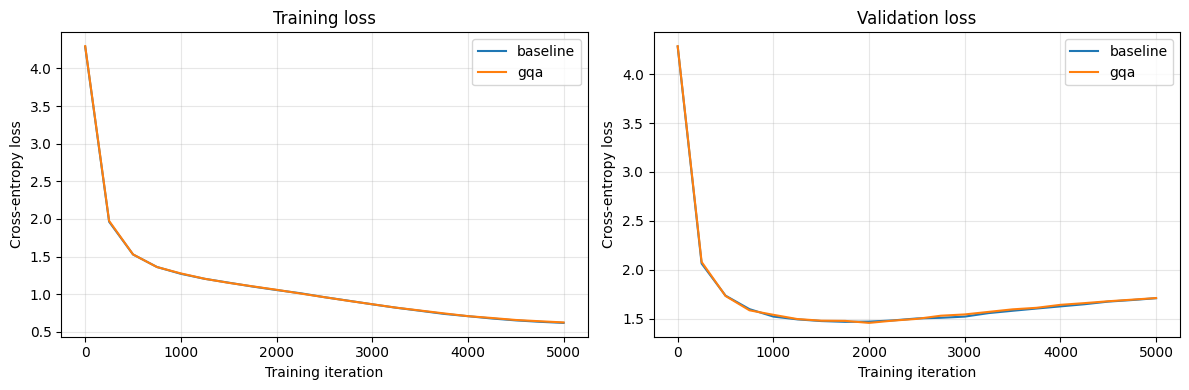

In [ ]:
from pathlib import Path
import re
import csv
import matplotlib.pyplot as plt

folder = Path("/content/drive/MyDrive/Homework1_nanoGPT")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name in ["baseline", "gqa"]:
    log = (folder / f"{name}_training.log").read_text()
    matches = re.findall(
        r"step (\d+): train loss ([\d.]+), val loss ([\d.]+)",
        log
    )
    rows = [(int(s), float(t), float(v)) for s, t, v in matches]
    assert rows and rows[-1][0] == 5000, f"Incomplete log: {name}"

    with (folder / f"{name}_losses.csv").open("w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["step", "train_loss", "val_loss"])
        writer.writerows(rows)

    steps, training, validation = zip(*rows)
    axes[0].plot(steps, training, label=name)
    axes[1].plot(steps, validation, label=name)

    best = min(rows, key=lambda row: row[2])
    print(f"{name}: best validation loss {best[2]:.4f}, step {best[0]}")

for ax, title in zip(axes, ["Training loss", "Validation loss"]):
    ax.set_title(title)
    ax.set_xlabel("Training iteration")
    ax.set_ylabel("Cross-entropy loss")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(folder / "baseline_vs_gqa.png", dpi=300)
plt.show()